# Takens embedding of the Lorenz attractor

This tutorial demonstrates how to:

1. Simulate the Lorenz system using `scipy.integrate.solve_ivp`.
2. Store the trajectory as a multi-channel `TimeSeries`.
3. Reconstruct the attractor from a single observed channel using
   `embed_time_delay` (Takens embedding).
4. Compute persistent homology of the embedding to detect the
   topological structure of the attractor.

The Lorenz system is a classic example of deterministic chaos. Its three
coupled ODEs produce a trajectory that traces out the famous
"butterfly" attractor in $(x, y, z)$ space. Takens' theorem tells us
that the topology of this attractor can be recovered from a
time-delayed embedding of just *one* of the three variables.

## Step 1: Simulate the Lorenz system

The Lorenz equations are:

$$
\dot{x} = \sigma(y - x), \quad
\dot{y} = x(\rho - z) - y, \quad
\dot{z} = xy - \beta z
$$

with the standard chaotic parameters $\sigma = 10$, $\rho = 28$,
$\beta = 8/3$.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp

def lorenz(t, state, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

# Integrate for 50 time units; discard the first 10 as transient
sol = solve_ivp(
    lorenz, [0, 50], y0=[1.0, 1.0, 1.0],
    max_step=0.01, dense_output=True,
)

# Sample at uniform dt = 0.01 after the transient
dt = 0.01
t_eval = np.arange(10.0, 50.0, dt)
xyz = sol.sol(t_eval)  # shape (3, n_times) — channels-first

print(f"Trajectory shape: {xyz.shape}")
print(f"Time range: [{t_eval[0]}, {t_eval[-1]}], dt = {dt}")

Trajectory shape: (3, 4000)
Time range: [10.0, 49.98999999999915], dt = 0.01


## Step 2: Store as a multi-channel TimeSeries

The three Lorenz variables become three channels of a single
`TimeSeries`. This captures the fact that they share a common time
axis.

In [2]:
import masspcf as mpcf

ts = mpcf.TimeSeries(xyz, start_time=t_eval[0], time_step=dt)

print(ts)
print(f"Channels: {ts.n_channels} (x, y, z)")
print(f"Time points: {ts.n_times}")

TimeSeries(start_time=10.0, n_times=4000, n_channels=3, dtype=ts64)
Channels: 3 (x, y, z)
Time points: 4000


Let's plot the three channels and the 3D attractor side by side.

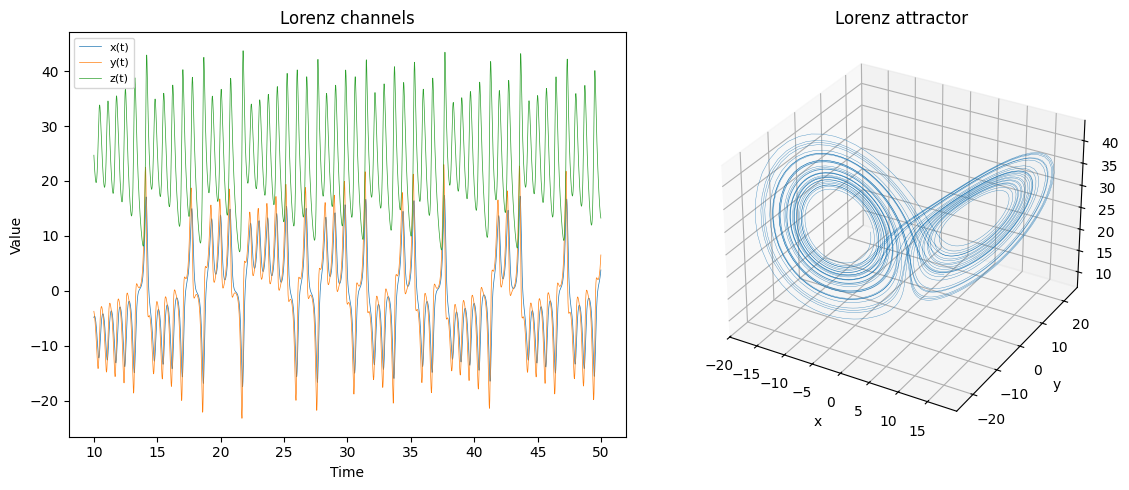

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

# Left: individual channels
ax_ts = fig.add_subplot(1, 2, 1)
labels = ["x(t)", "y(t)", "z(t)"]
for ch in range(3):
    ax_ts.plot(t_eval, xyz[ch], linewidth=0.5, label=labels[ch])
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("Value")
ax_ts.set_title("Lorenz channels")
ax_ts.legend(fontsize=8)

# Right: 3D attractor
ax_3d = fig.add_subplot(1, 2, 2, projection="3d")
ax_3d.plot(xyz[0], xyz[1], xyz[2], linewidth=0.3, alpha=0.8)
ax_3d.set_xlabel("x")
ax_3d.set_ylabel("y")
ax_3d.set_zlabel("z")
ax_3d.set_title("Lorenz attractor")

fig.tight_layout()
plt.show()

## Step 3: Takens embedding from a single channel

Takens' theorem guarantees that, for a generic observation function and
a sufficiently high embedding dimension, the delay embedding is
diffeomorphic to the original attractor. In practice, embedding the
$x$ channel with dimension 3 and an appropriate delay already recovers
the butterfly shape.

We extract the $x$ channel into its own `TimeSeries` and embed it.

In [4]:
# Extract the x channel
ts_x = mpcf.TimeSeries(xyz[0], start_time=t_eval[0], time_step=dt)

# Takens embedding: dimension 3, delay chosen as 15 * dt = 0.15
tau = 15 * dt
cloud = mpcf.embed_time_delay(ts_x, dimension=3, delay=tau)
pts = np.asarray(cloud[0])

print(f"Embedding: {pts.shape[0]} points in {pts.shape[1]}D")

Embedding: 3970 points in 3D


Let's compare the original 3D attractor with the reconstructed one.

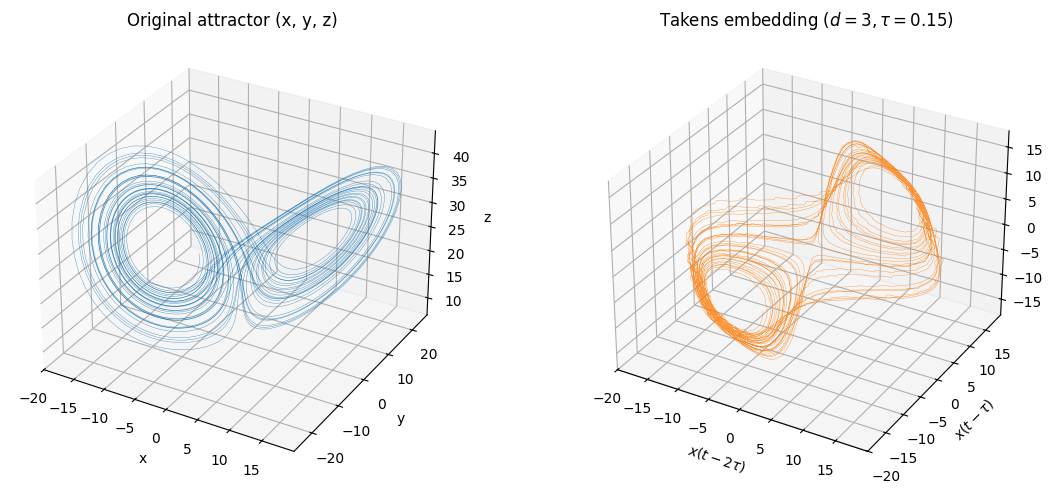

In [5]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(xyz[0], xyz[1], xyz[2], linewidth=0.3, alpha=0.8)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.set_title("Original attractor (x, y, z)")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot(pts[:, 0], pts[:, 1], pts[:, 2], linewidth=0.3, alpha=0.8,
         color="C1")
ax2.set_xlabel(r"$x(t - 2\tau)$")
ax2.set_ylabel(r"$x(t - \tau)$")
ax2.set_zlabel(r"$x(t)$")
ax2.set_title(rf"Takens embedding ($d=3, \tau={tau}$)")

fig.tight_layout()
plt.show()

## Step 4: Persistent homology of the embedding

The Lorenz attractor is too large to run Ripser on the full point
cloud, so we subsample before computing persistent homology. Even a
moderate subsample reveals the H1 loops in the attractor.

In [6]:
from masspcf.persistence import (
    compute_persistent_homology,
    barcode_to_stable_rank,
)

# Subsample for tractable computation
rng = np.random.default_rng(0)
idx = rng.choice(len(pts), size=400, replace=False)
sub = pts[idx]

barcodes = compute_persistent_homology(sub, max_dim=1)
sranks = barcode_to_stable_rank(barcodes)

print(f"Barcodes shape: {barcodes.shape}")
print(f"Stable ranks shape: {sranks.shape}")

Barcodes shape: Shape(2)
Stable ranks shape: Shape(2)


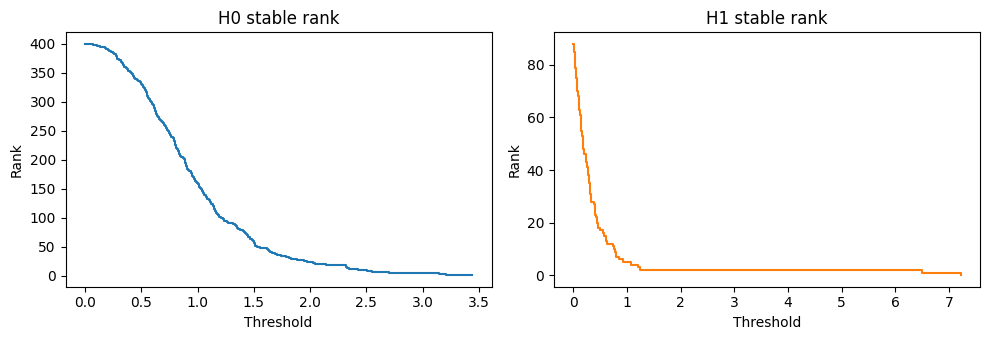

In [7]:
from masspcf.plotting import plot as plotpcf

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

plotpcf(sranks[0], ax=axes[0], color="C0")
axes[0].set_title("H0 stable rank")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Rank")

plotpcf(sranks[1], ax=axes[1], color="C1")
axes[1].set_title("H1 stable rank")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Rank")

fig.tight_layout()
plt.show()

The stable-regime windows (blue) have zero H1 stable rank — the
decaying signal produces no loops in the embedding. The chaotic windows
(orange) show large H1 ranks, reflecting the loop structure of the
Lorenz attractor. The windowed embedding cleanly detects the transition
from stable to chaotic dynamics.

### Key takeaways

- **Multi-channel `TimeSeries`** naturally represents a multivariate
  dynamical system with a shared time axis.
- **`embed_time_delay`** reconstructs the geometry of the underlying
  attractor from a single observed variable.
- **Windowed embedding** splits the trajectory into time windows, each
  producing its own point cloud — useful for detecting regime changes
  or transitions in the dynamics.
- The resulting point clouds plug directly into masspcf's persistence
  pipeline (`compute_persistent_homology` → `barcode_to_stable_rank`)
  for topological feature extraction.

## Step 5: Detecting regime change with windowed embedding

The Lorenz system's behavior depends on the parameter $\rho$. For
$\rho < 1$ the origin is globally stable and the signal decays to zero
(no oscillation). For $\rho = 28$ the dynamics are chaotic and the
trajectory traces out the butterfly attractor with prominent loops.

By simulating a system that transitions between these regimes and
applying windowed embedding, we can detect the onset of chaos
topologically: windows in the stable regime produce point clouds with no
H1 features, while chaotic windows show clear loops.

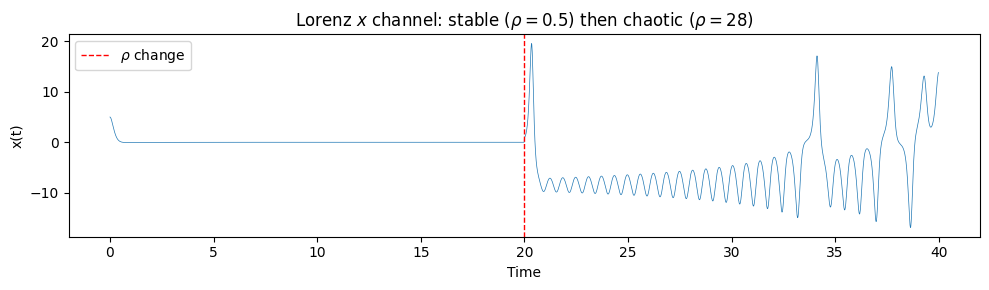

In [8]:
# Regime 1 (t=0..20): rho=0.5, stable fixed point, signal decays to zero
sol_stable = solve_ivp(
    lambda t, s: lorenz(t, s, rho=0.5),
    [0, 20], y0=[5.0, 5.0, 5.0], max_step=0.01, dense_output=True,
)
# Regime 2 (t=20..40): rho=28, chaotic attractor
sol_chaotic = solve_ivp(
    lambda t, s: lorenz(t, s, rho=28.0),
    [0, 20], y0=[1.0, 1.0, 1.0], max_step=0.01, dense_output=True,
)

t_regime = np.arange(0, 20, dt)
x_stable = sol_stable.sol(t_regime)[0]
x_chaotic = sol_chaotic.sol(t_regime)[0]

x_combined = np.concatenate([x_stable, x_chaotic])
t_combined = np.arange(len(x_combined)) * dt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_combined, x_combined, linewidth=0.5)
ax.axvline(20.0, color="red", linestyle="--", linewidth=1, label=r"$\rho$ change")
ax.set_xlabel("Time")
ax.set_ylabel("x(t)")
ax.set_title(r"Lorenz $x$ channel: stable ($\rho=0.5$) then chaotic ($\rho=28$)")
ax.legend()
fig.tight_layout()
plt.show()

Windows: 8


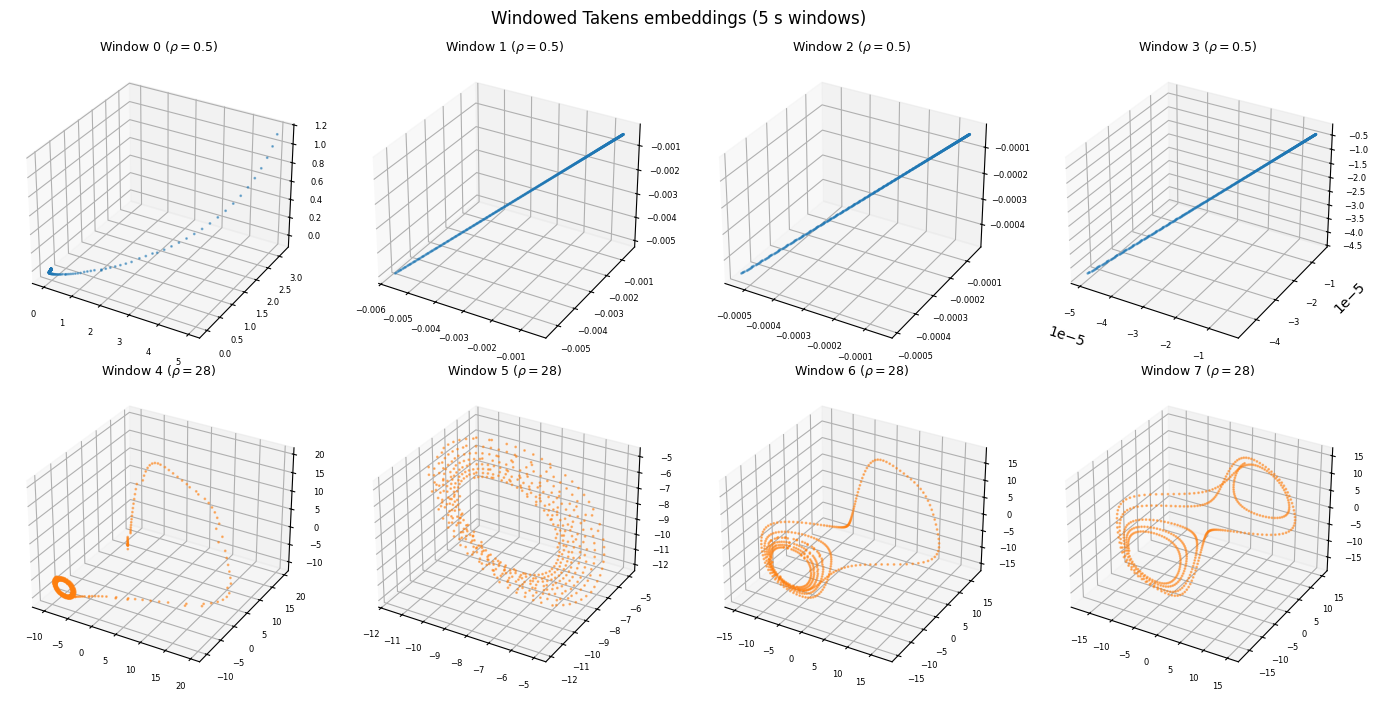

In [9]:
# Windowed embedding: 5-second non-overlapping windows
ts_combined = mpcf.TimeSeries(x_combined, start_time=0.0, time_step=dt)
windowed = mpcf.embed_time_delay(ts_combined, dimension=3, delay=tau, window=5.0)
n_win = windowed.shape[0]
print(f"Windows: {n_win}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7),
                          subplot_kw={"projection": "3d"})

for i, ax in enumerate(axes.flat):
    if i >= n_win:
        ax.set_visible(False)
        continue
    w_pts = np.asarray(windowed[i])
    ax.scatter(w_pts[:, 0], w_pts[:, 1], w_pts[:, 2],
               s=1, alpha=0.5,
               color="C0" if i < 4 else "C1")
    regime = r"$\rho=0.5$" if i < 4 else r"$\rho=28$"
    ax.set_title(f"Window {i} ({regime})", fontsize=9)
    ax.tick_params(labelsize=6)

fig.suptitle("Windowed Takens embeddings (5 s windows)", fontsize=12)
fig.tight_layout()
plt.show()

The stable-regime windows collapse to a near-zero point cloud, while the
chaotic windows trace out the familiar butterfly. Computing persistent
homology per window makes this quantitative.

In [10]:
win_barcodes = compute_persistent_homology(windowed, max_dim=1)
win_sranks = barcode_to_stable_rank(win_barcodes)

print(f"Per-window stable ranks shape: {win_sranks.shape}")

Per-window stable ranks shape: Shape(8, 2)


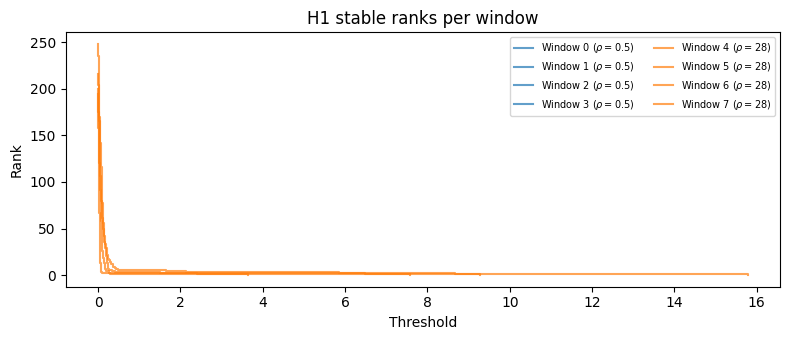

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))

for i in range(n_win):
    color = "C0" if i < 4 else "C1"
    regime = r"$\rho=0.5$" if i < 4 else r"$\rho=28$"
    plotpcf(win_sranks[i, 1], ax=ax, alpha=0.7, color=color,
            label=f"Window {i} ({regime})")

ax.set_title("H1 stable ranks per window")
ax.set_xlabel("Threshold")
ax.set_ylabel("Rank")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()